# 03 - Epilepsy demographics

Do we keep children in the data or not? 22/123 PWE are <20 years old. 


Notes:
- some SEQN numbers from the DEMO table do not show up in the PAXHD table for year G: `[62767.0, 68550.0, 68903.0, 70744.0]`. Do they show up in the LUX files?

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import pyreadstat
import matplotlib.pyplot as plt


import ambient_light_epilepsy.nhanes as nhn
import ambient_light_epilepsy.cohort as ch
import time

In [2]:
# -----------------------------------------------------------------------------
# Functions for exploring demographics
# -----------------------------------------------------------------------------

def check_seqn_have_lux(year, common_seqn):
    # Define the base directory
    data_dir = Path(f"W:/projects/ambient_light_epilepsy_analysis/data/PAXLUX_{year}/parquet_5min")
    
    # 1. Generate the expected filenames for every index in your common_indices
    # This assumes SEQN is a prefix and the index replaces 'idxnum'
    missing_files = []
    existing_files = []
    
    for idxnum in common_seqn:
        # Construct the specific filename
        file_path = data_dir / f"SEQN_{int(idxnum)}_5min.parquet"
        
        if file_path.exists():
            existing_files.append(file_path)
        else:
            missing_files.append(idxnum)
    
    # 2. Report the results
    if not missing_files:
        print(f"✅ Success! All {len(common_seqn)} files exist.")
    else:
        print(f"❌ Missing {len(missing_files)} files.")
        print(f"The following indices lack a parquet file: {missing_files}")



def show_distribution(df_dict, match_cols):
    """
    Displays value distributions for multiple DataFrames side-by-side.
    df_dict: dict of {Label: DataFrame}
    match_cols: list of columns to compare
    """
    for col in match_cols:
        # Create a list of series for the current column across all dataframes
        series_to_compare = {}
        
        for label, df in df_dict.items():
            series_to_compare[label] = df[col].value_counts(normalize=True).round(3)
        
        # Concat handles the alignment of index labels (e.g., matching '30-39' rows)
        comparison_df = pd.concat(series_to_compare, axis=1).fillna(0)
        
        # Formatting the output
        header = " | ".join([f"=== {label} ===" for label in df_dict.keys()])
        print(f"\n{header}")
        print("-" * len(header))
        print(f"COLUMN: {col}")
        print(comparison_df)
        print("\n")




def plot_matched_distributions(
    df_pwe,
    df_controls,
    age_col="age",
    discrete_cols=None,
    bins=15,
):
    """
    Creates a 5-panel comparison plot:
    - Panel 1: Overlaid age histogram
    - Remaining panels: Side-by-side bar charts for discrete variables
    
    Parameters
    ----------
    df_pwe : DataFrame
    df_controls : DataFrame
    age_col : str
        Column name for age
    discrete_cols : list
        List of categorical columns to plot (length should be 4)
    bins : int
        Number of bins for age histogram
    """

    if discrete_cols is None:
        raise ValueError("Provide list of 4 discrete columns to plot.")

    if len(discrete_cols) != 4:
        raise ValueError("Function expects exactly 4 discrete columns.")

    fig, axes = plt.subplots(1, 5, figsize=(22, 5))

    # --------------------------
    # Panel 1: Age histogram
    # --------------------------
    axes[0].hist(
        df_pwe[age_col].dropna(),
        bins=bins,
        density=True,
        alpha=0.5,
        label="PWE",
    )

    axes[0].hist(
        df_controls[age_col].dropna(),
        bins=bins,
        density=True,
        alpha=0.5,
        label="Controls",
    )

    axes[0].set_title("Age distribution")
    axes[0].set_xlabel("Age (years)")
    axes[0].set_ylabel("Density")
    axes[0].legend()

    # --------------------------
    # Panels 2–5: Discrete vars
    # --------------------------
    for i, col in enumerate(discrete_cols):
        ax = axes[i + 1]

        # Normalized counts
        pwe_dist = df_pwe[col].value_counts(normalize=True)
        ctrl_dist = df_controls[col].value_counts(normalize=True)

        # Align categories
        combined = pd.concat(
            [pwe_dist, ctrl_dist],
            axis=1,
            keys=["PWE", "Controls"]
        ).fillna(0)

        categories = combined.index
        x = np.arange(len(categories))
        width = 0.35

        ax.bar(
            x - width/2,
            combined["PWE"],
            width,
            label="PWE"
        )

        ax.bar(
            x + width/2,
            combined["Controls"],
            width,
            label="Controls"
        )

        ax.set_xticks(x)
        ax.set_xticklabels(categories, rotation=45, ha="right")
        ax.set_ylim(0, combined.max().max() * 1.1)
        ax.set_title(col)

        if i == 0:
            ax.legend()

    plt.tight_layout()
    plt.show()



# -----------------------------------------------------------------------------
# Functions for ferquency macthing
# -----------------------------------------------------------------------------
def bin_age(df_column):
    # Define bins: 0, 20, 25, 30 ... 80
    bins = [0, 20] + list(range(25, 81, 5)) + [np.inf]
    
    # Define labels: "0-19", "20-24", ... "80+"
    labels = ["0–19", "20–24", "25–29", "30–34", "35–39", 
              "40–44", "45–49", "50–54", "55–59", "60–64", 
              "65–69", "70–74", "75–79", "80+"]
    
    return pd.cut(df_column, bins=bins, labels=labels, right=False)



def find_frequency_matched_controls(df_demo_all, df_demo_pwe, control_ratio=4):
    
    df_demo_all = df_demo_all.copy()
    df_demo_pwe = df_demo_pwe.copy()

    # Create an age bin
    df_demo_all["age_bin"] = bin_age(df_demo_all["age"])
    df_demo_pwe["age_bin"] = bin_age(df_demo_pwe["age"])

    # Define the matching variables
    match_cols = [
        "age_bin",
        "sex_label",
        "race_label",
        "season",
        "PIR_cat",
    ]
    
    # Drop rows that have missing data in the matching vars
    df_demo_pwe_m = df_demo_pwe.dropna(subset=match_cols)
    df_demo_all_m = df_demo_all.dropna(subset=match_cols)
    
    
    # Remove PWE from the control pool
    pwe_seqns = set(df_demo_pwe_m.index)
    df_controls_pool = df_demo_all_m.loc[~df_demo_all_m.index.isin(pwe_seqns)].copy()
    
    # Calculate the number of PWE in each multivariate bin
    pwe_freq = (
        df_demo_pwe_m
        .groupby(match_cols, observed=False)
        .size()
        .reset_index(name="n_pwe")
    )

    
    # Set random seed
    rng = np.random.default_rng(42)
    
    # Loop through all multivariate bins and identify control participants 
    matched_controls = []
    
    for _, row in pwe_freq.iterrows():
        strata_filter = (
            (df_controls_pool["age_bin"] == row["age_bin"]) &
            (df_controls_pool["sex_label"] == row["sex_label"]) &
            (df_controls_pool["race_label"] == row["race_label"]) &
            (df_controls_pool["season"] == row["season"]) &
            (df_controls_pool["PIR_cat"] == row["PIR_cat"])
        )
    
        eligible = df_controls_pool.loc[strata_filter]
    
        n_needed = row["n_pwe"] * control_ratio
    
        if len(eligible) == 0:
            continue  # no matches available for this stratum
    
        # Sample without replacement if possible, otherwise take all
        n_sample = min(len(eligible), n_needed)
    
        sampled = eligible.sample(
            n=n_sample,
            replace=False,
            random_state=rng.integers(0, 1e9)
        )
    
        matched_controls.append(sampled)

    # Save as a data frame
    df_controls_matched = pd.concat(matched_controls)

    # Print summary of numbers
    print("Number of PWE:", len(df_demo_pwe_m))
    print("Number of matched controls:", len(df_controls_matched))


    return df_controls_matched, df_demo_pwe_m


def save_machting_results(df_controls_matched, df_demo_pwe_m, year, match_type="freq"):
        
        save_dir = Path(f"C:/Users/ahernj/Documents/Projects/ambient_light_epilepsy_analysis/data/{year}/processed")
        control_path = save_dir / f"{match_type}_match_control_{year}.csv"
        pwe_path = save_dir / f"{match_type}_match_pwe_{year}.csv"
    
    
        pd.Series(df_controls_matched.index.values).to_csv(control_path)
        pd.Series(df_demo_pwe_m.index.values).to_csv(pwe_path)



In [8]:



def find_matched_controls(year, describe_demo=False):
    
    # -----------------------------
    # Filter participants by:
    #     - age > 20
    #     - valid LUX file lasting 8 days
    # -----------------------------
    
    # Load partial demographics table
    demo_full = nhn.load_partial_demo(year)
    
    # Filter by age to get adults only (>20)
    demo_adults = demo_full[demo_full['age'] >= 20]
    
    # Load SEQN numbers for people with epilepsy
    pwe_idx = pd.Index(ch.load_pwe_seqn(year).values.reshape(-1))
    
    # Use PAXHD get valid LUX file of 9 days
    hd = nhn.load_PAXHD(year)
    valid_lux_idx = hd[(hd["PAXSTS"] == 1) & (hd["PAXLDAY"] == '9')].index
    
    # Find common indices
    common_seqn = demo_adults.index.intersection(pwe_idx).intersection(valid_lux_idx)
    
    # Check that all seqn have a LUX file
    check_seqn_have_lux(year, common_seqn)
    
    
    # -----------------------------
    # Create readable demographics tables
    # -----------------------------
    
    # Data frame of demographics for all adults with a valid LUX measurement
    df_demo_all = demo_adults.loc[demo_adults.index.intersection(valid_lux_idx)]
    df_demo_all = nhn.add_demo_labels(df_demo_all) 
    
    # Data frame of demograpics for all adults with epilpesy with valid LUX
    df_demo_pwe = demo_adults.loc[common_seqn]
    df_demo_pwe = nhn.add_demo_labels(df_demo_pwe)
    
    
    
    
    # -----------------------------
    # Find macthed controls
    # -----------------------------
    
    
    # Find healthy matched controls and save the results 
    df_controls_matched, df_demo_pwe_m = find_frequency_matched_controls(df_demo_all, df_demo_pwe)
    save_machting_results(df_controls_matched, df_demo_pwe_m, year, match_type="freq")
    
    
    # Ensure that there are no duplicates in controls
    if df_controls_matched.index.nunique() < len(df_controls_matched):
        print("ERROR: Duplicates in control sample")
    else:
        print("✅ All control participants are unique")
    
    
    # Print the disributions of matched variables 
    show_distribution(
        {"PWE": df_demo_pwe_m, "Matched controls": df_controls_matched}, 
        match_cols=[
            "age_bin",
            "sex_label",
            "race_label",
            "season",
            "PIR_cat"
        ]
    )
    
    # Plot the distribution of macthed varaibles
    plot_matched_distributions(
        df_demo_pwe_m,
        df_controls_matched,
        age_col="age",
        discrete_cols=[
            "sex_label",
            "race_label",
            "season",
            "PIR_cat"
        ]
    )
    
    
    
    
    
    
    if describe_demo==True:
    
        # -----------------------------
        # Print summaries of numberic values
        # -----------------------------
        print(f"=== Age ({year}) ===")
        print(df_demo_pwe["age"].describe())
        n_lt_20 = (df_demo_pwe["age"]<20).sum()
        print(f"Number of people younger than 20: {n_lt_20}")
        
        print(f"\n=== Household size ({year}) ===")
        print(df_demo_pwe["NIH"].describe())
        
        print(f"\n=== Income-to-poverty ratio (PIR) ({year}) ===")
        print(df_demo_pwe["PIR"].describe())
        
        
        # -----------------------------
        # Summarize discrete values
        # -----------------------------
        def summarize(series, name):
            print(f"\n=== {name} ===")
            print(series.value_counts(dropna=False))
            print(
                (series.value_counts(normalize=True, dropna=False) * 100)
                .round(1)
                .astype(str) + "%"
            )
        
        summarize(df_demo_pwe["sex_label"], f"Sex ({year})")
        summarize(df_demo_pwe["season"], f"Season ({year})")
        summarize(df_demo_pwe["race_label"], f"Race / Ethnicity ({year})")
        summarize(df_demo_pwe["education_label"], f"Education ({year})")
        summarize(df_demo_pwe["PIR_cat"], f"Income-to-poverty ratio ({year})")
        
        
        # -----------------------------
        # Create figures
        # -----------------------------
        fig, Ax = plt.subplots(1, 4, figsize=(15,4), tight_layout=True)
        
        
        # Age
        ax = Ax[0]
        ax.hist(df_demo_pwe["age"].dropna(), bins=20)
        ax.set_xlabel("Age (years)")
        ax.set_ylabel("Number of participants")
        ax.set_title(f"Age distribution of people with epilepsy ({year})")
        
        # Sex
        ax = Ax[1]
        df_demo_pwe["sex_label"].value_counts().plot(kind="bar", ax=ax)
        ax.set_ylabel("Number of participants")
        ax.set_title(f"Sex distribution ({year})")
    
        
        # Ethnicity
        ax = Ax[2]
        df_demo_pwe["race_label"].value_counts().plot(kind="bar", ax=ax)
        ax.set_ylabel("Number of participants")
        ax.set_title(f"face / ethnicity ({year})")
        ax.tick_params(axis='x', labelrotation=45) 
    
        
        # Education
        ax = Ax[3]
        df_demo_pwe["education_label"].value_counts().plot(kind="bar", ax=ax)
        ax.set_ylabel("Number of participants")
        ax.set_title(f"Education level ({year})")
        ax.tick_params(axis='x', labelrotation=45) 

✅ Success! All 87 files exist.
Number of PWE: 82
Number of matched controls: 276
✅ All control participants are unique

=== PWE === | === Matched controls ===
--------------------------------------
COLUMN: age_bin
           PWE  Matched controls
age_bin                         
35–39    0.159             0.152
45–49    0.110             0.123
50–54    0.110             0.112
60–64    0.110             0.101
55–59    0.098             0.101
65–69    0.098             0.094
70–74    0.073             0.058
30–34    0.061             0.069
25–29    0.049             0.051
20–24    0.037             0.036
75–79    0.037             0.029
40–44    0.037             0.043
80+      0.024             0.029
0–19     0.000             0.000



=== PWE === | === Matched controls ===
--------------------------------------
COLUMN: sex_label
             PWE  Matched controls
sex_label                         
Female     0.561             0.551
Male       0.439             0.449



=== PWE === | ==

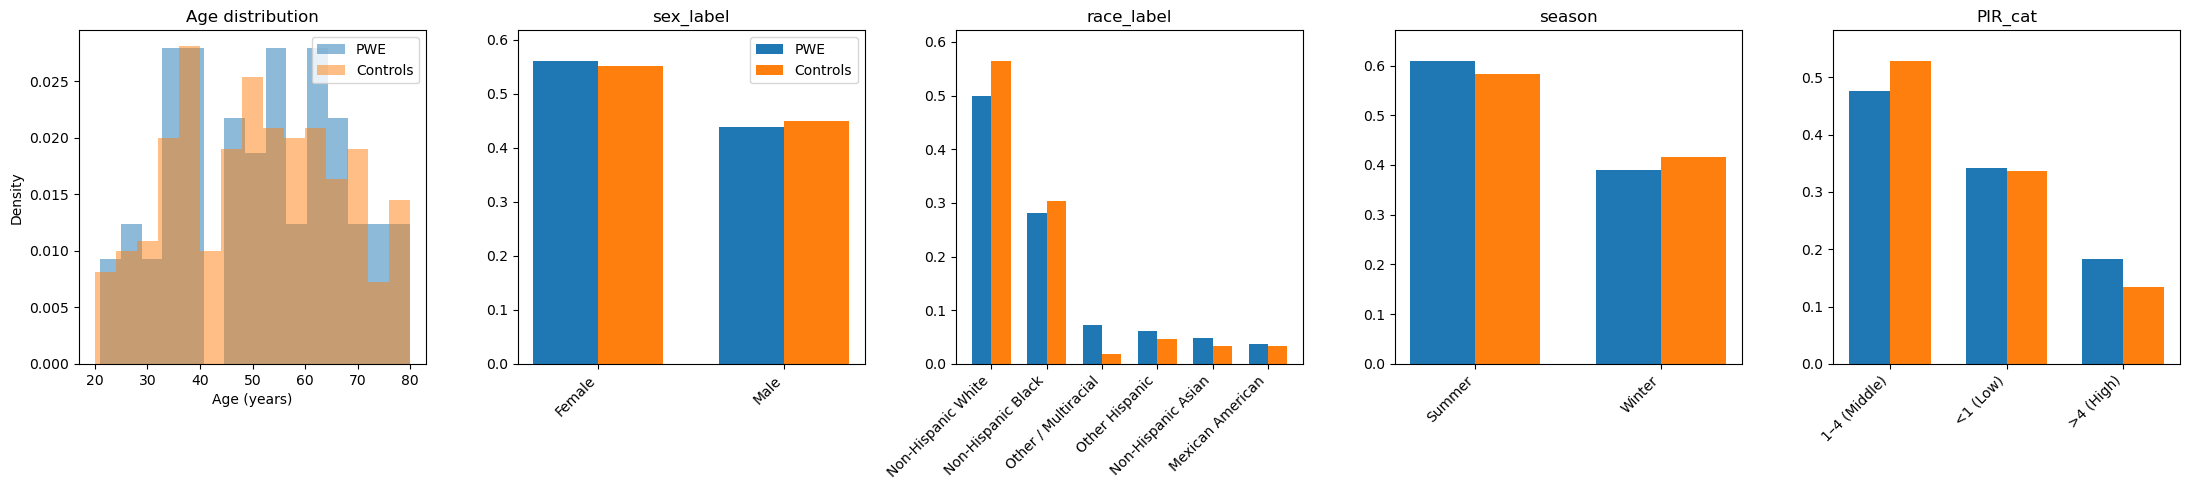

In [9]:
find_matched_controls("G")

✅ Success! All 115 files exist.
Number of PWE: 110
Number of matched controls: 393
✅ All control participants are unique

=== PWE === | === Matched controls ===
--------------------------------------
COLUMN: age_bin
           PWE  Matched controls
age_bin                         
50–54    0.173             0.170
55–59    0.118             0.120
60–64    0.100             0.092
45–49    0.100             0.102
40–44    0.091             0.102
30–34    0.091             0.087
35–39    0.082             0.092
70–74    0.055             0.053
20–24    0.055             0.053
75–79    0.045             0.036
80+      0.036             0.038
25–29    0.036             0.038
65–69    0.018             0.018
0–19     0.000             0.000



=== PWE === | === Matched controls ===
--------------------------------------
COLUMN: sex_label
             PWE  Matched controls
sex_label                         
Female     0.555             0.567
Male       0.445             0.433



=== PWE === | 

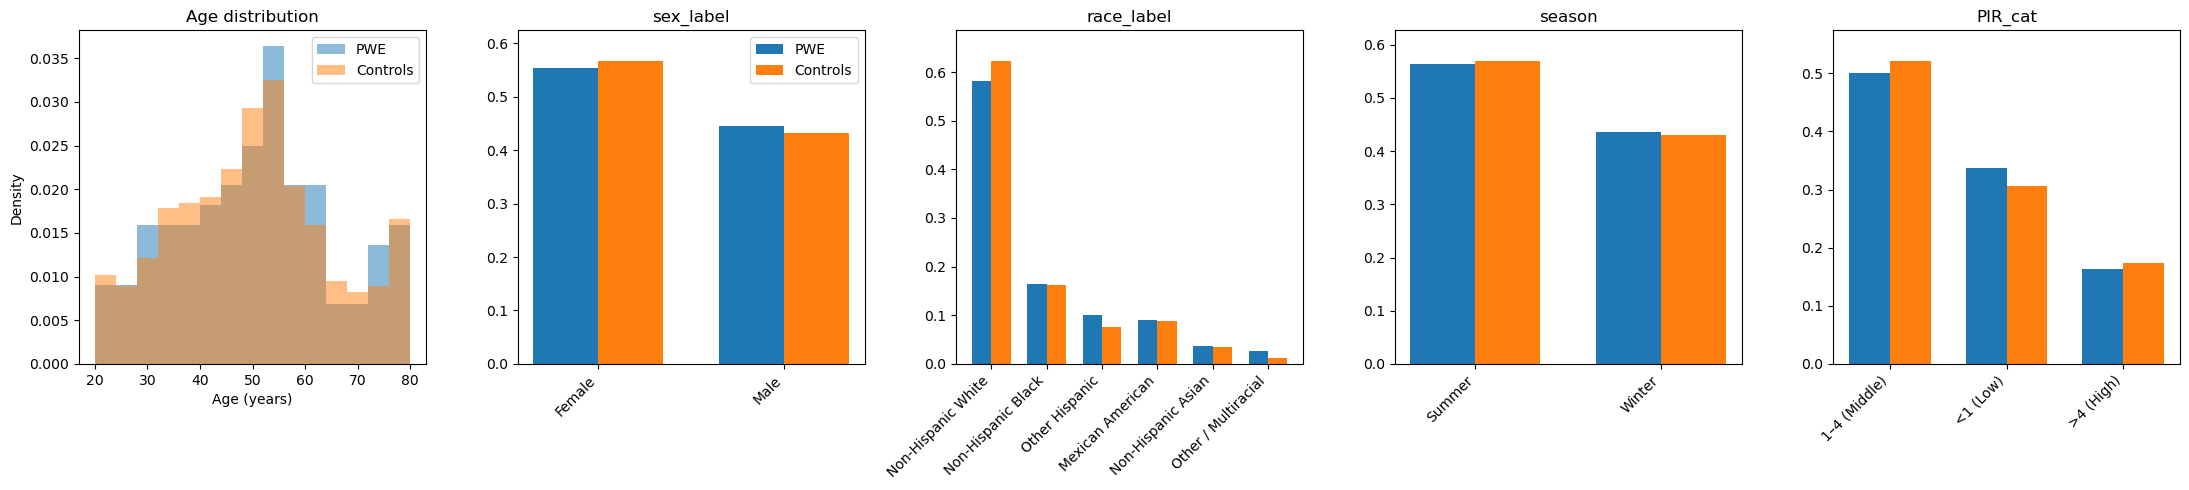

In [10]:
find_matched_controls("H")

## Frequency matching control group selection 

Number of PWE: 110
Number of matched controls: 393


✅ All control participants are unique

=== PWE === | === Matched controls ===
--------------------------------------
COLUMN: age_bin
           PWE  Matched controls
age_bin                         
50–54    0.173             0.170
55–59    0.118             0.120
60–64    0.100             0.092
45–49    0.100             0.102
40–44    0.091             0.102
30–34    0.091             0.087
35–39    0.082             0.092
70–74    0.055             0.053
20–24    0.055             0.053
75–79    0.045             0.036
80+      0.036             0.038
25–29    0.036             0.038
65–69    0.018             0.018
0–19     0.000             0.000



=== PWE === | === Matched controls ===
--------------------------------------
COLUMN: sex_label
             PWE  Matched controls
sex_label                         
Female     0.555             0.567
Male       0.445             0.433



=== PWE === | === Matched controls ===
--------------------------------------
COLUMN: race_label


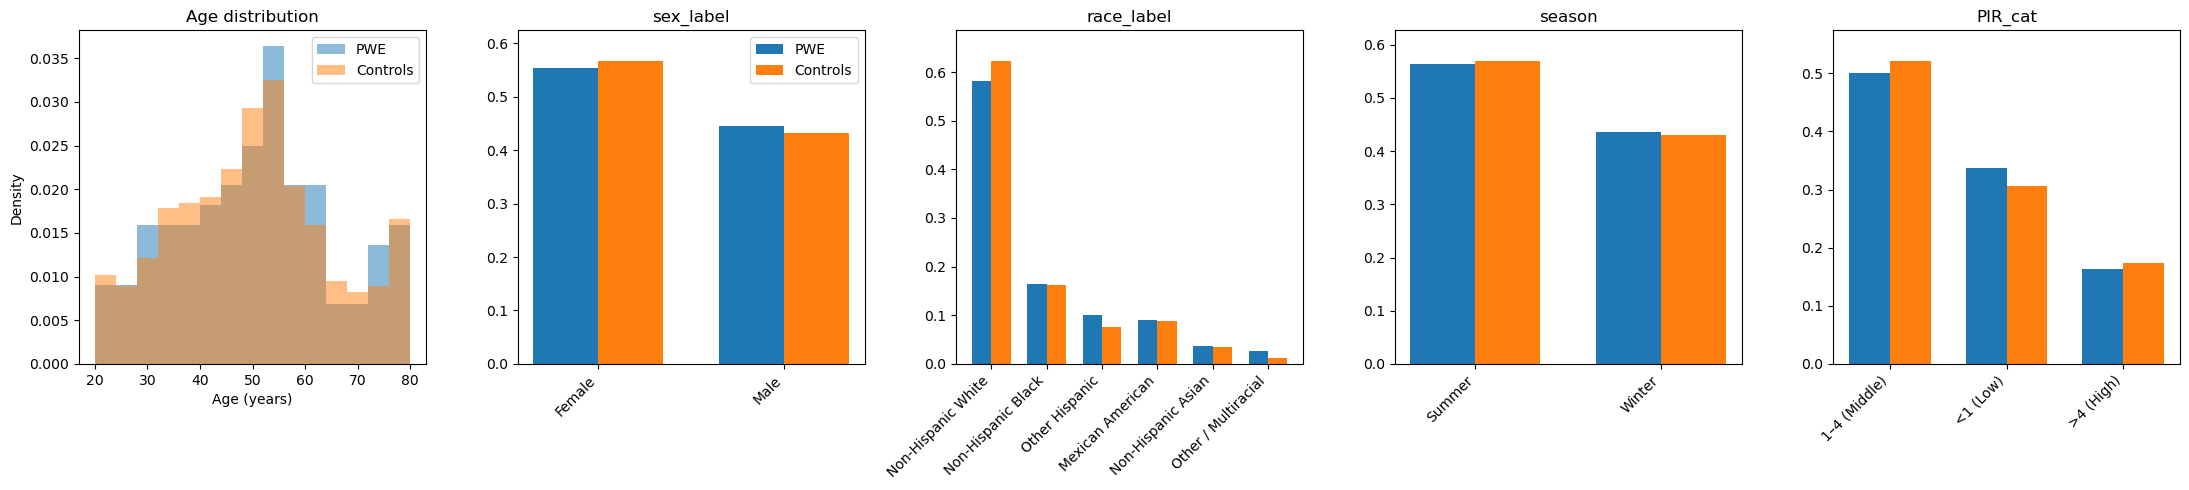

In [14]:
# Find healthy matched controls and save the results 
df_controls_matched, df_demo_pwe_m = find_frequency_matched_controls(df_demo_all, df_demo_pwe)
save_machting_results(df_controls_matched, df_demo_pwe_m, year, match_type="freq")


# Ensure that there are no duplicates in controls
if df_controls_matched.index.nunique() < len(df_controls_matched):
    print("ERROR: Duplicates in control sample")
else:
    print("✅ All control participants are unique")


# Print the disributions of matched variables 
show_distribution(
    {"PWE": df_demo_pwe_m, "Matched controls": df_controls_matched}, 
    match_cols=[
        "age_bin",
        "sex_label",
        "race_label",
        "season",
        "PIR_cat"
    ]
)

# Plot the distribution of macthed varaibles
plot_matched_distributions(
    df_demo_pwe_m,
    df_controls_matched,
    age_col="age",
    discrete_cols=[
        "sex_label",
        "race_label",
        "season",
        "PIR_cat"
    ]
)